In [18]:
%pip install matplotlib
import re
import pandas as pd
from typing import Dict
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


In [19]:
class TextPreprocessor:

    def clean_text(self, text: str) -> str:
        if pd.isna(text) or not text:
            return ""

        text = str(text).lower()

        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'http\S+|www\.\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)

        text = re.sub(r'[^a-zA-Z0-9\s\.,!?+#-]', ' ', text)

        text = ' '.join(text.split())

        words = text.split()
        words = [w for w in words if len(w) <= 50]

        return ' '.join(words)

Apply Preprocessing Methods

In [20]:
jobs = pd.read_csv('../data/processed/jobs_updated.csv')

In [21]:
jobs_after = jobs.copy(deep=True)

In [22]:
PREPROCESSOR = TextPreprocessor()

In [23]:
jobs_after["skills_desc"] = jobs_after["skills_desc"].apply(
    lambda x: x[:1000].rsplit(" ", 1)[0] if isinstance(x, str) and len(x) > 1000 else x
)

jobs_after["description"] = jobs_after["description"].apply(
    lambda x: x[:2000] if isinstance(x, str) else x
)

In [24]:
jobs_after["title_clean"] = jobs_after["title"].apply(PREPROCESSOR.clean_text)

jobs_after["skills_clean"] = jobs_after["skills_desc"].apply(PREPROCESSOR.clean_text)

jobs_after["description_clean"] = jobs_after["description"].apply(PREPROCESSOR.clean_text)

Inspect Embedded Text

In [25]:
jobs_after["title_len"] = jobs_after["title_clean"].str.len()
jobs_after["skills_len"] = jobs_after["skills_clean"].str.len()
jobs_after["description_len"] = jobs_after["description_clean"].str.len()

print("Title length:", jobs_after["title_len"].describe())
print("Skills length:", jobs_after["skills_len"].describe())
print("Description length:", jobs_after["description_len"].describe())

Title length: count    123849.000000
mean         31.113178
std          15.745657
min           0.000000
25%          20.000000
50%          28.000000
75%          39.000000
max         194.000000
Name: title_len, dtype: float64
Skills length: count    123849.000000
mean        185.124603
std         238.789097
min           0.000000
25%           0.000000
50%          93.000000
75%         274.000000
max         999.000000
Name: skills_len, dtype: float64
Description length: count    123849.000000
mean       1826.229198
std         367.336191
min           0.000000
25%        1952.000000
50%        1979.000000
75%        1988.000000
max        2000.000000
Name: description_len, dtype: float64


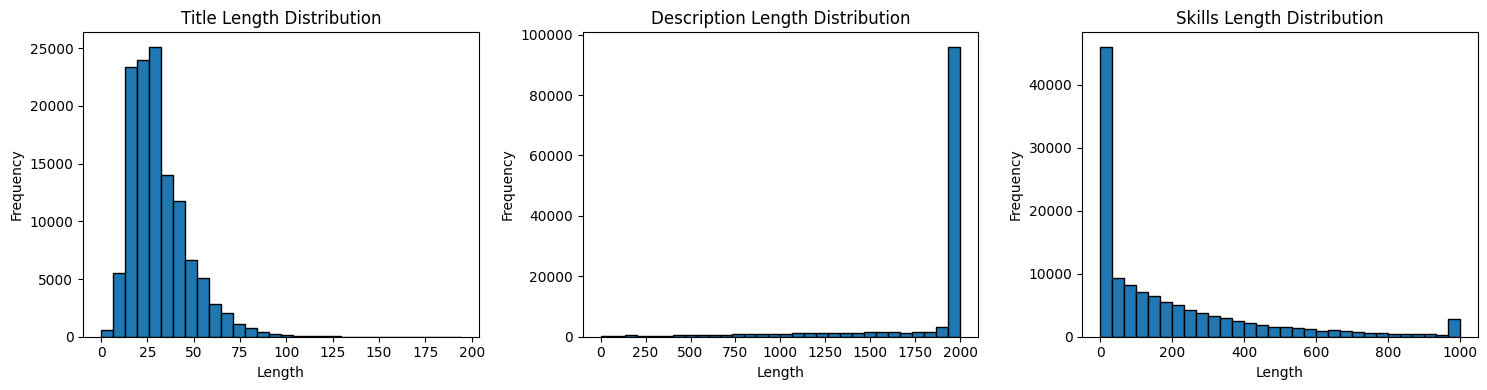

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(jobs_after["title_len"], bins=30, edgecolor='black')
axes[0].set_title('Title Length Distribution')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency')

axes[1].hist(jobs_after["description_len"], bins=30, edgecolor='black')
axes[1].set_title('Description Length Distribution')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency')

axes[2].hist(jobs_after["skills_len"], bins=30, edgecolor='black')
axes[2].set_title('Skills Length Distribution')
axes[2].set_xlabel('Length')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Save Cleaned And Processed Data

In [27]:
import json
from datetime import datetime
import os

In [28]:
os.makedirs('data/processed', exist_ok=True)

In [29]:

jobs_after.to_csv('data/processed/jobs_preprocessed.csv', index=False)

file_size = os.path.getsize('data/processed/jobs_preprocessed.csv') / 1e6

In [30]:
job_ids_path = 'data/processed/job_ids.csv'
jobs_after[['job_id']].to_csv(job_ids_path, index=False)

In [31]:
summary = {
    'preprocessing_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_jobs': len(jobs_after),

    #Dataset size
    'rows_before_cleaning': int(len(jobs)),
    'rows_after_cleaning': int(len(jobs_after)),
    
    # Skills coverage
    'skill_coverage': {
        'has_skills': int(jobs_after['skills_desc'].notna().sum()),
        'missing': int(jobs_after['skills_desc'].isna().sum()),
        'percentage': float(jobs_after['skills_desc'].notna().sum() / len(jobs_after) * 100)
    },
    
    # Experience coverage
    'experience_coverage': {
        'specified': int(jobs_after['formatted_experience_level'].notna().sum()),
        'not_specified': int(jobs_after['formatted_experience_level'].isna().sum()),
        'percentage': float(jobs_after['formatted_experience_level'].notna().sum() / len(jobs_after) * 100)
    },
    
    # Experience distribution
    'experience_distribution': jobs_after['formatted_experience_level'].value_counts(dropna=False).to_dict(),
    
    # Text statistics per column
    'text_statistics': {
        'title': {
            'mean_length': float(jobs_after['title_clean'].str.len().mean()),
            'median_length': float(jobs_after['title_clean'].str.len().median()),
            'min_length': int(jobs_after['title_clean'].str.len().min()),
            'max_length': int(jobs_after['title_clean'].str.len().max())
        },
        'description': {
            'mean_length': float(jobs_after['description_clean'].str.len().mean()),
            'median_length': float(jobs_after['description_clean'].str.len().median()),
            'min_length': int(jobs_after['description_clean'].str.len().min()),
            'max_length': int(jobs_after['description_clean'].str.len().max())
        },
        'skills_desc': {
            'mean_length': float(jobs_after['skills_clean'].str.len().mean()),
            'median_length': float(jobs_after['skills_clean'].str.len().median()),
            'min_length': int(jobs_after['skills_clean'].str.len().min()),
            'max_length': int(jobs_after['skills_clean'].str.len().max())
        },
    },
    
    # Columns
    'columns': list(jobs_after.columns),
    
    # Next step
    'next_step': 'Generate embeddings separately per column for recommendation model'
}

In [32]:
summary_path = 'data/processed/preprocessing_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

In [33]:
print('data/processed/jobs_preprocessed.csv')

data/processed/jobs_preprocessed.csv


In [34]:


# Check the notebook's current working directory
print("Current directory:", os.getcwd())

# Check if the file exists
print("File exists?", os.path.exists("data/processed/jobs_preprocessed.csv"))

# Show absolute path
print("Full path:", os.path.abspath("data/processed/jobs_preprocessed.csv"))

Current directory: c:\Users\patel\Downloads\job-recommendation-engine-recovered\notebooks
File exists? True
Full path: c:\Users\patel\Downloads\job-recommendation-engine-recovered\notebooks\data\processed\jobs_preprocessed.csv
